In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
from scipy import signal
import math
import matplotlib.patches as patches

Fig3bc.csv
[4416.073 4411.069 4410.433 ... 4409.377 4413.518 4408.147]


C:\Users\bachd\AppData\Local\Temp\ipykernel_31052\96942466.py:19: DeprecationWarning: dtype=object is not supported by sosfilt and will raise an error in SciPy 1.17.0. Supported dtypes are: boolean, integer, `np.float16`,`np.float32`, `np.float64`, `np.complex64`, `np.complex128`.
  R_f = signal.sosfilt(sos, R)


<Figure size 640x480 with 0 Axes>

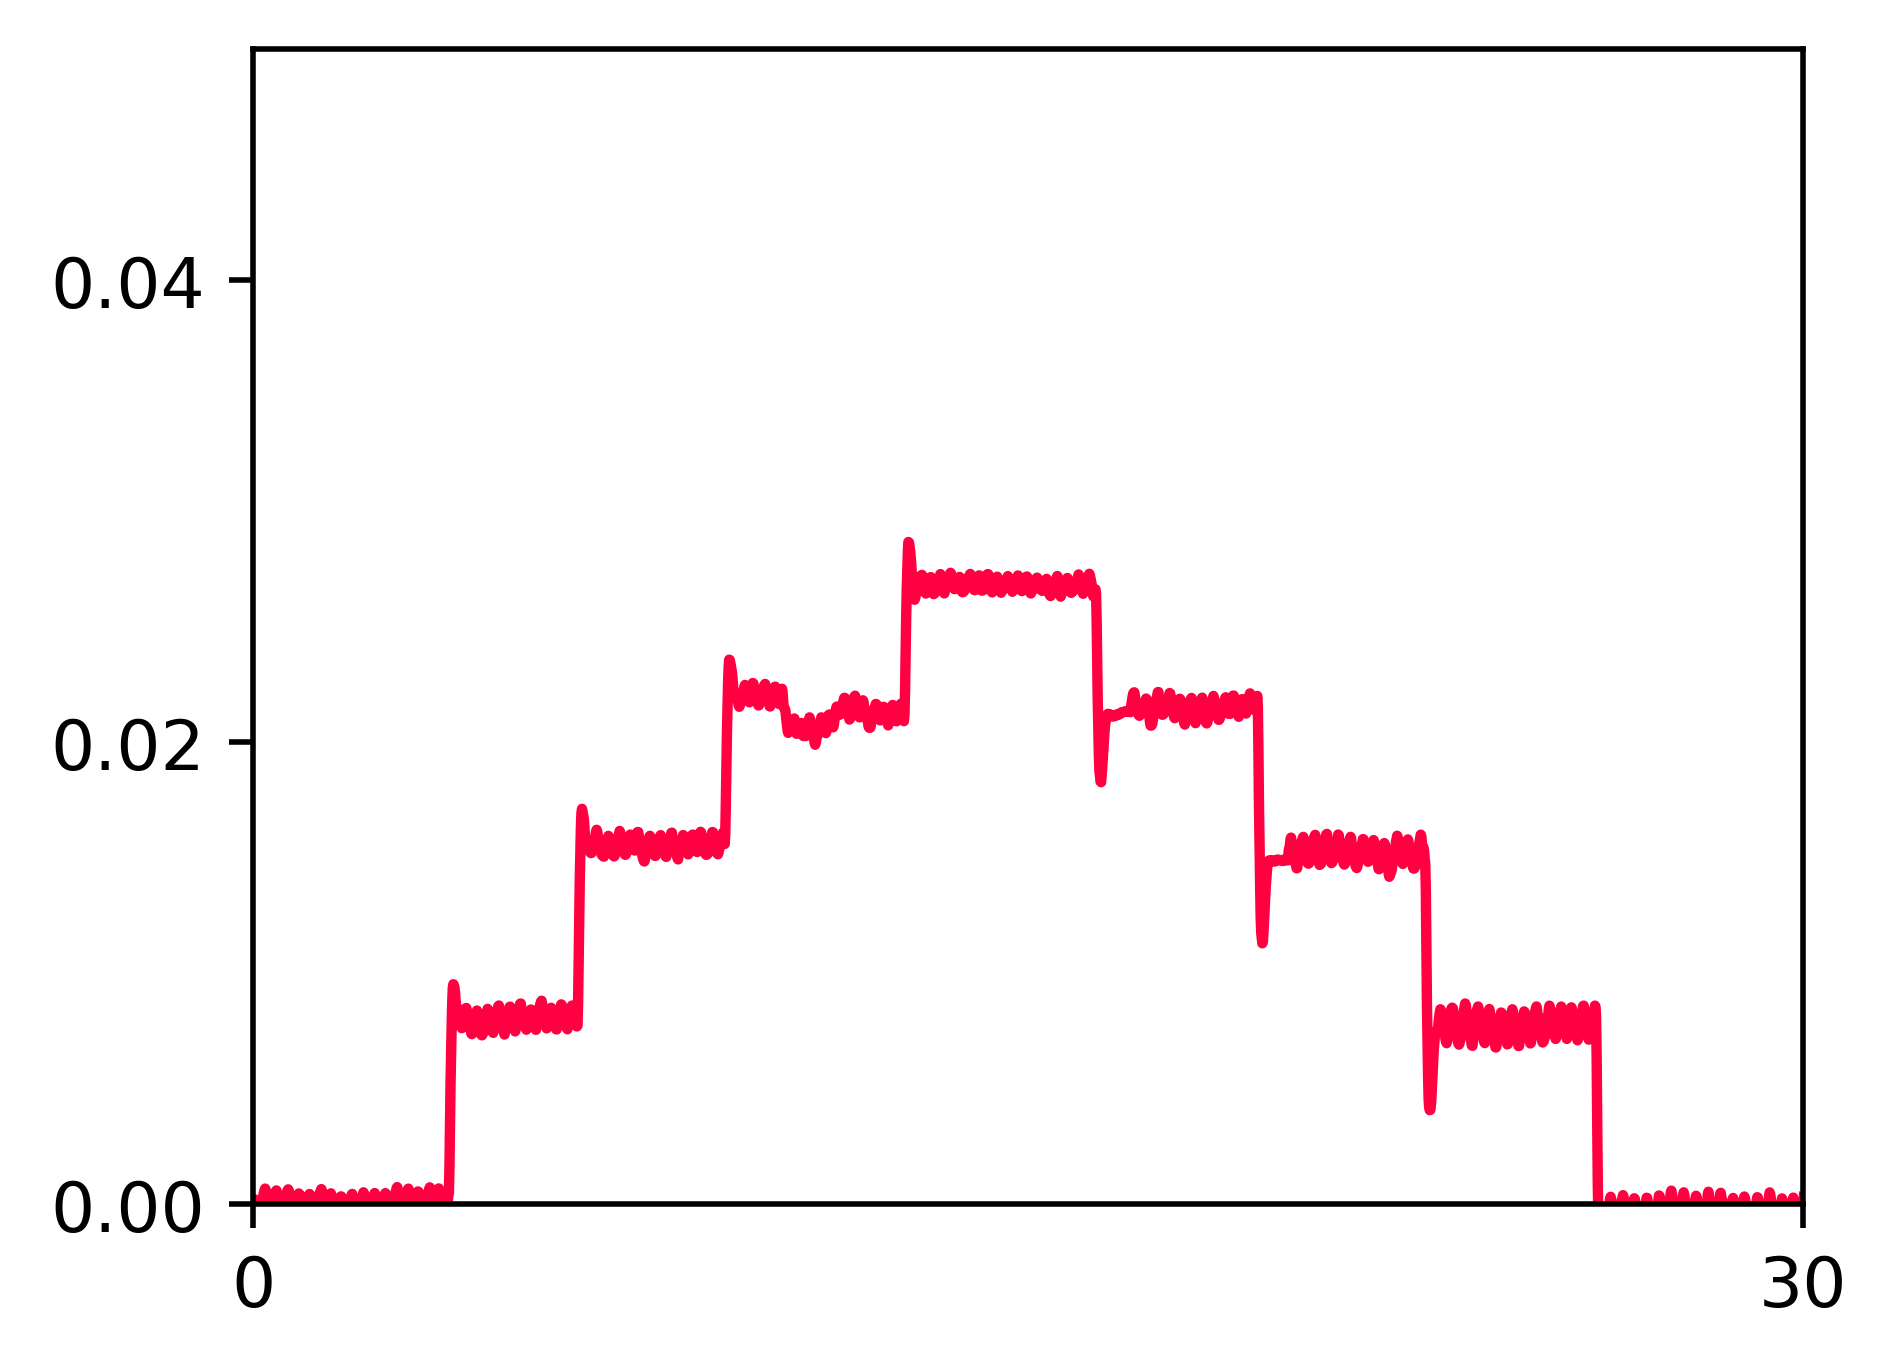

In [3]:
for file in glob.glob('Fig3b*.csv'):
    plt.clf()
    plt.figure(figsize=[4, 3], dpi=500, frameon=False)
    plt.locator_params(axis='y', nbins=4)
    # plt.axis('off')
    # plt.xlabel('Time (s)')
    # plt.ylabel('Resistance (Ohm)')
    plt.ylim([0, 0.05])
    plt.xlim(0, 30)
    plt.xticks([0, 30])
    print(file)
    a = np.array(pd.read_csv(file))[6000:, 2]
    t = np.linspace(0, len(a)/92, len(a))
    t = np.array(t, dtype='float')
    print(a)

    R = (-np.mean(a[:100])+a)/np.mean(a[:100])
    sos = signal.butter(1, 30, 'lp', fs=1000, output='sos')
    R_f = signal.sosfilt(sos, R)
    R_f = np.array(R_f, dtype='float')

    plt.plot(t, R_f, color="#FF0040")
    # plt.fill_between(t, 0, R_f, alpha=.1, color="#FF0040")
    # plt.savefig('fP_R_realtime.png', dpi=500)
    plt.show()

0.0006954855870211502
0.0008327318016165928


C:\Users\bachd\AppData\Local\Temp\ipykernel_31052\2080535947.py:18: DeprecationWarning: dtype=object is not supported by sosfilt and will raise an error in SciPy 1.17.0. Supported dtypes are: boolean, integer, `np.float16`,`np.float32`, `np.float64`, `np.complex64`, `np.complex128`.
  R_f = signal.sosfilt(sos, R)


<Figure size 640x480 with 0 Axes>

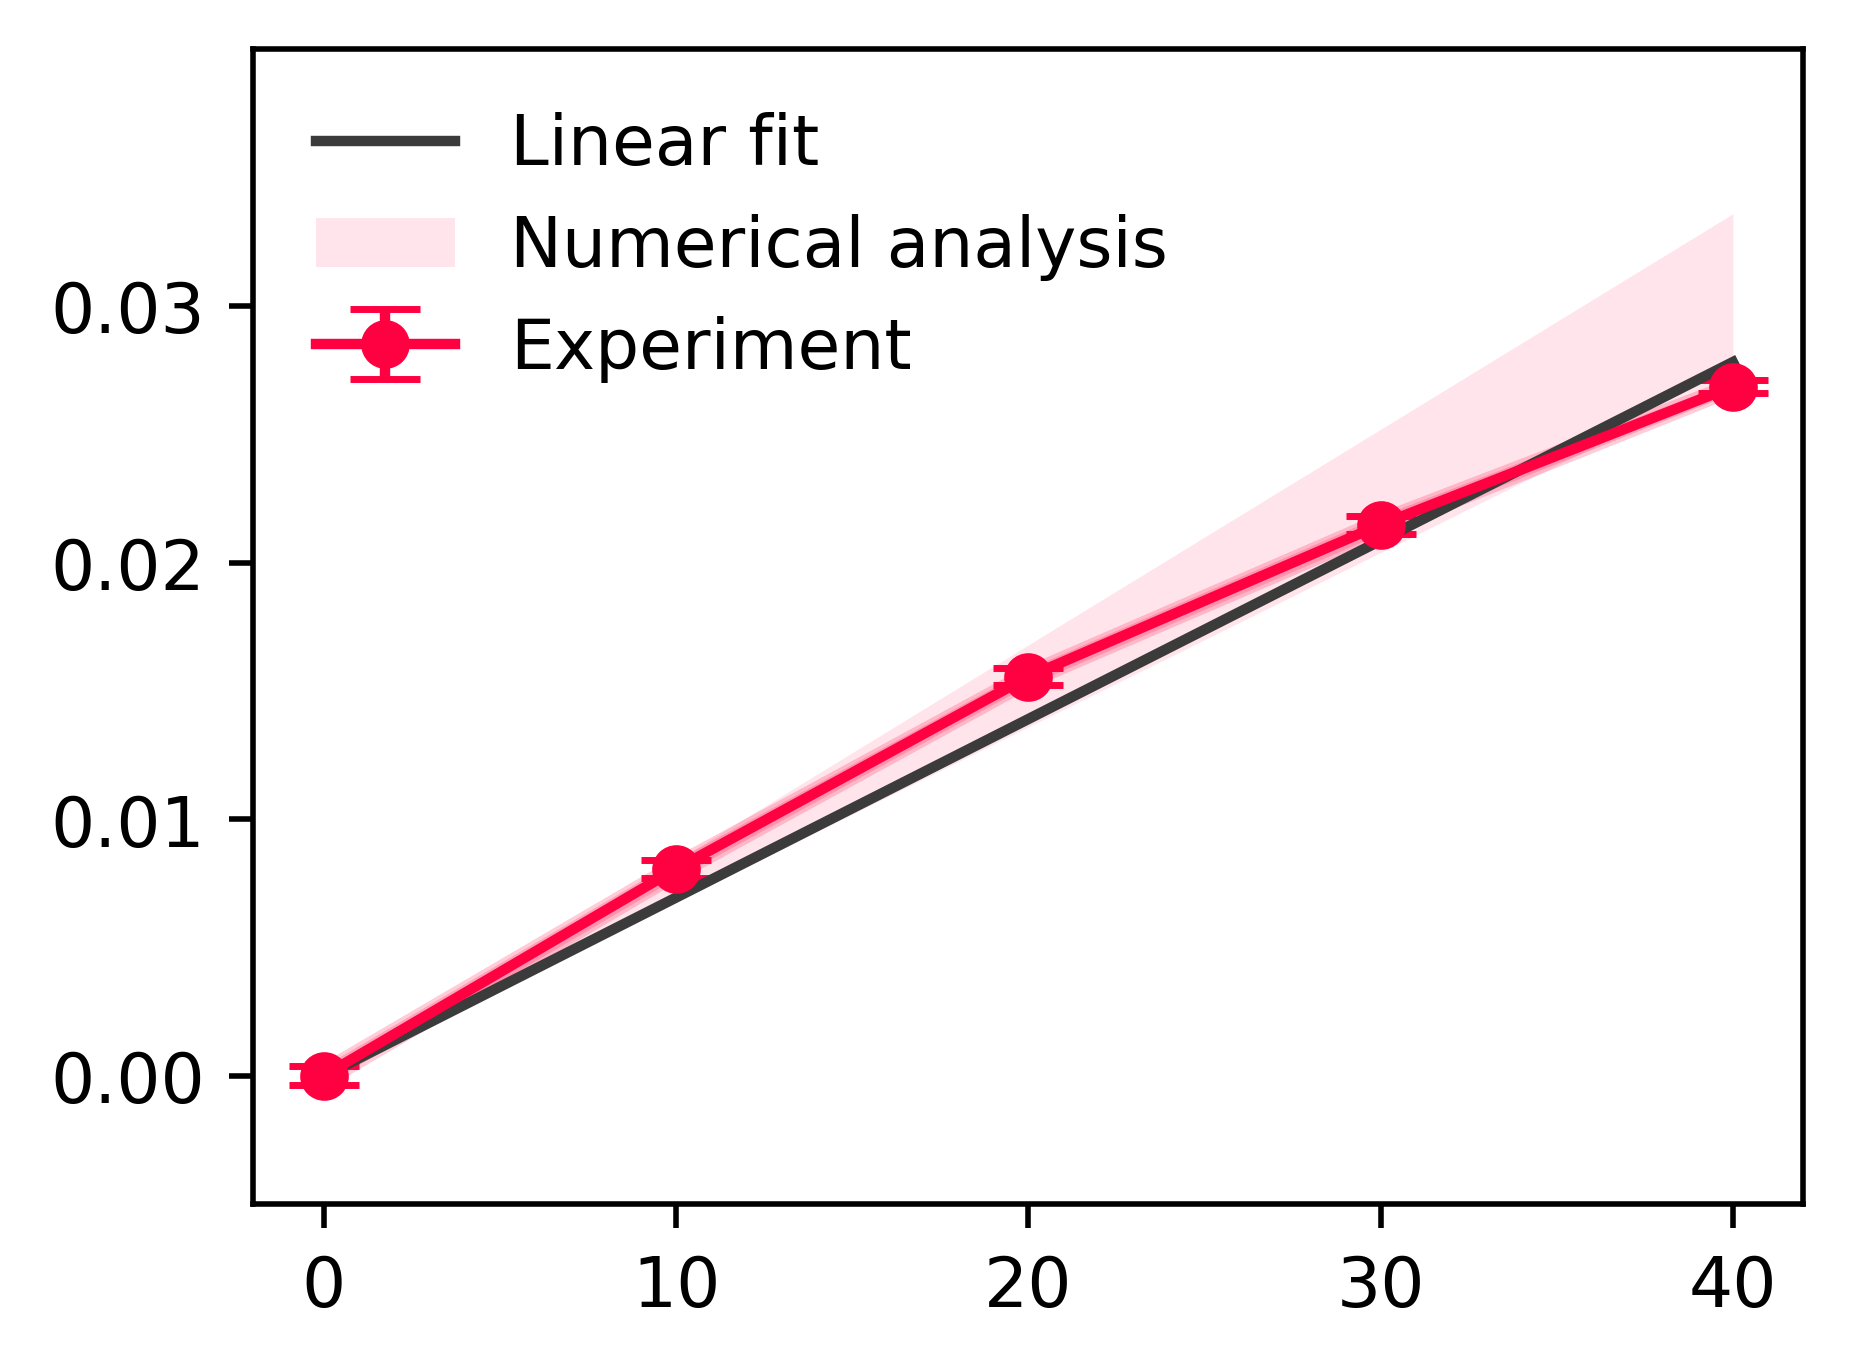

In [6]:
for file in glob.glob('Fig3b*.csv'):
    plt.clf()
    plt.figure(figsize=[4, 3], dpi=500, frameon=False)
    plt.locator_params(axis='y', nbins=4)
    # plt.axis('off')
    p = [0, 10, 20, 30, 40]
    plt.xticks(p)
    plt.ylim([-0.005, 0.04])
    plt.yticks([0, 0.01, 0.02, 0.03])
    # plt.xlabel('Time (s)')
    # plt.ylabel('Resistance (Ohm)')
    a = np.array(pd.read_csv(file))[5950:, 2]
    t = np.linspace(0, len(a)/100, len(a))
    t = np.array(t, dtype='float')

    R = (-np.mean(a[:100])+a)/np.mean(a[:100])
    sos = signal.butter(1, 30, 'lp', fs=1000, output='sos')
    R_f = signal.sosfilt(sos, R)

    R2 = R_f[:]
    R_p = []
    S_p = []
    for i in [0, 450, 650, 1600, 1250]:
        R_p.append(np.mean(R2[i:i+150]))
        # plt.plot(R2[i:i+150])
        S_p.append(R2[i:i+150].std(ddof=0))
    R_p = np.array(R_p)
    S_p = np.array(S_p)
    # plt.plot(p, R_p,'--ob')
    plt.errorbar(p, R_p, S_p, ls='-', marker='o', color="#FF0040", capsize=5, capthick=1, label='Experiment')
    plt.fill_between(p, R_p-S_p, R_p+S_p, alpha=.2, color="#FF0040")

    coef = np.polyfit(p,R_p,1)
    poly1d_fn = np.poly1d(coef) 
    q = np.linspace(0, 40, 5)
    plt.plot([0, 40], [0, poly1d_fn(40)], color='#3B3B3B', label='Linear fit')
    plt.fill_between([0, 40], [0, 6.8*40*1E-4], [0, 8.4*40*1E-4], alpha=.1, color="#FF0040", linewidth=0, label='Numerical analysis')
    print(poly1d_fn(40)/40)
    plt.legend(frameon=False)
# plt.savefig('fP_R.png', dpi=500)
MSE = np.square(np.subtract(R_p,poly1d_fn(q))).mean() 

RMSE = math.sqrt(MSE)
print(RMSE)

Fig3d.csv
122


<Figure size 640x480 with 0 Axes>

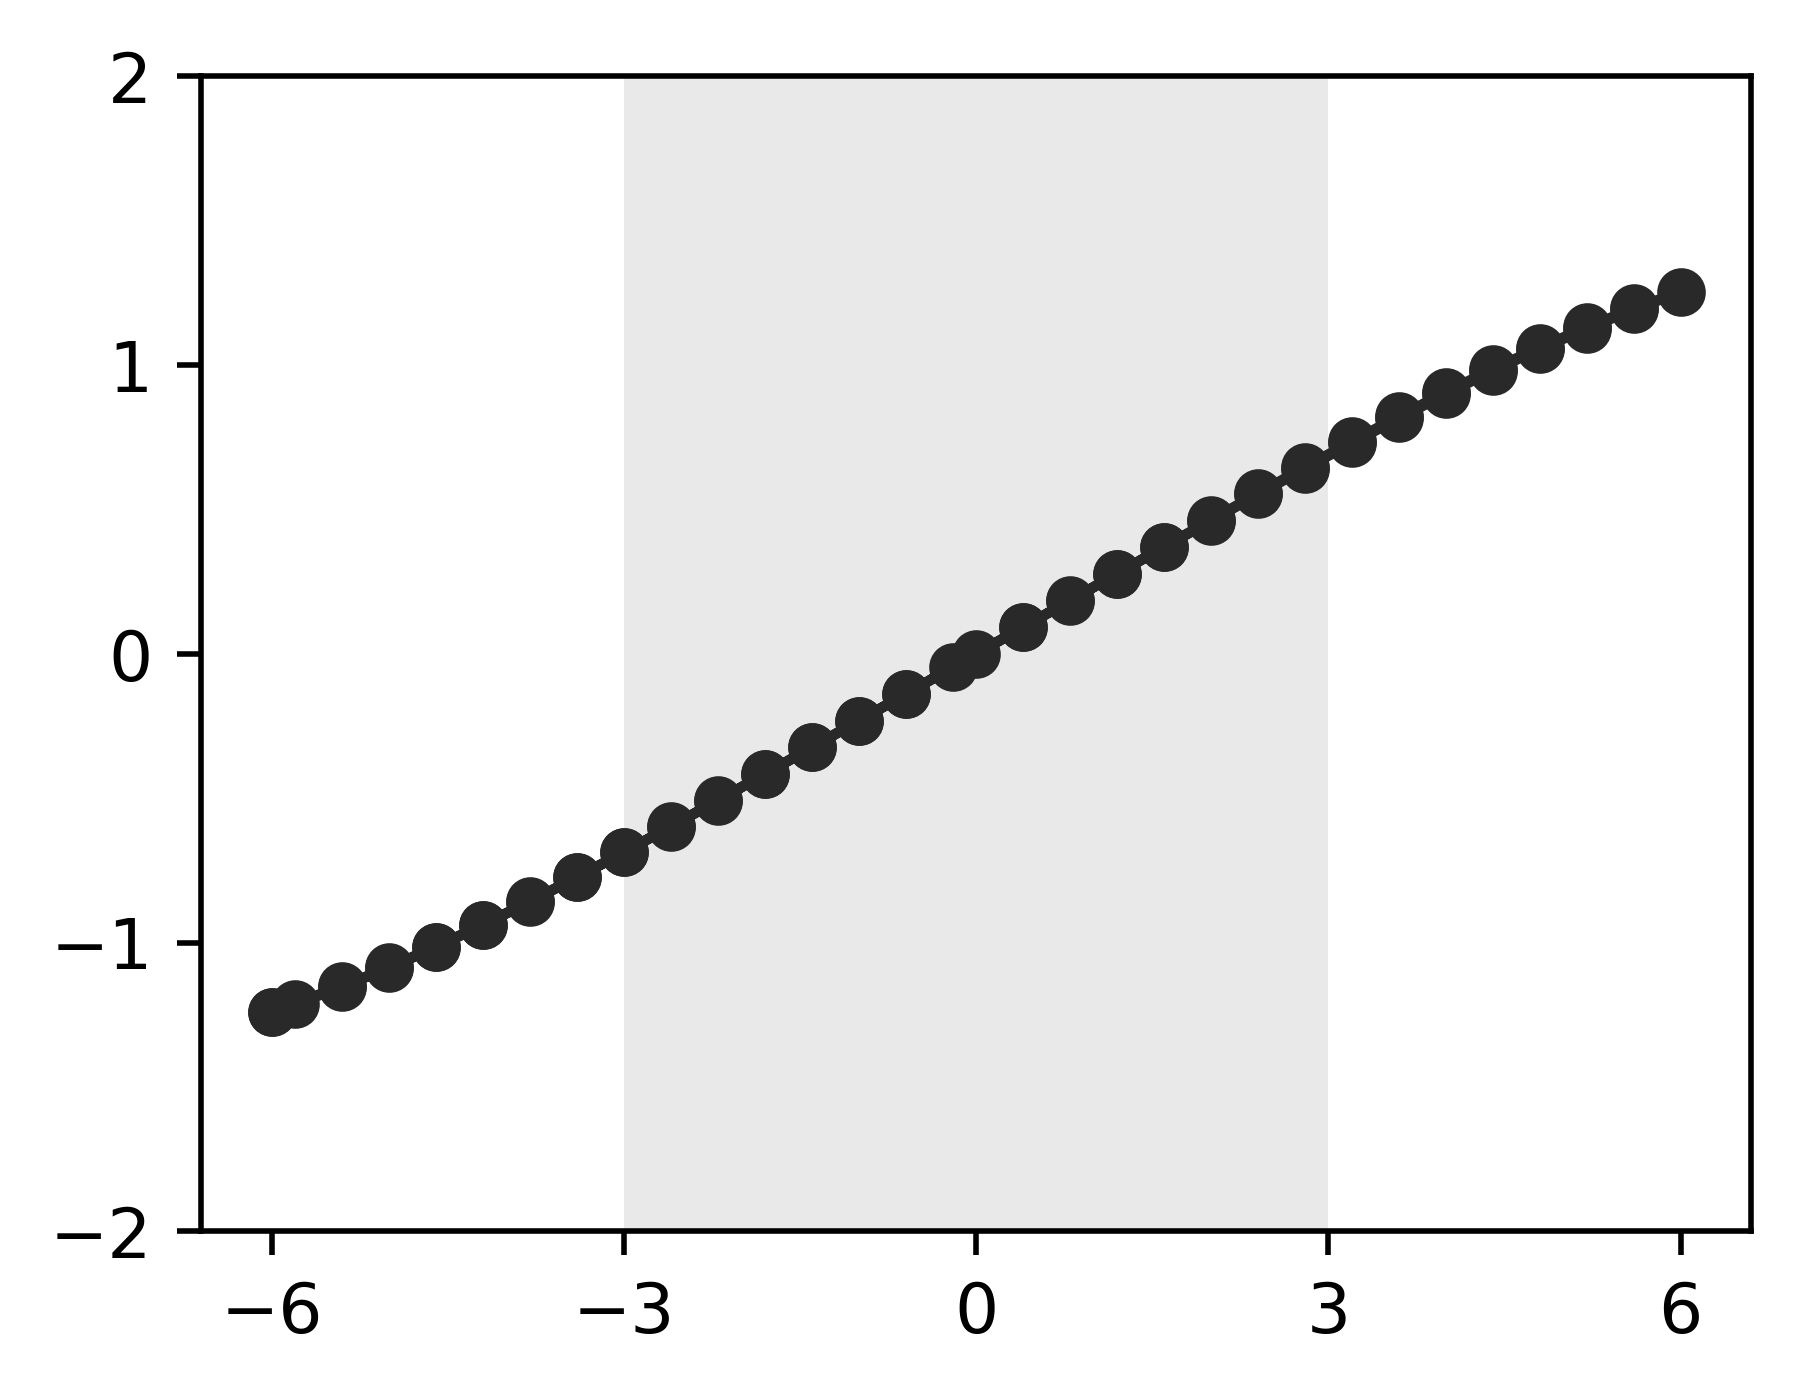

In [7]:
for file in glob.glob('Fig3d*.csv'):
    plt.clf()
    plt.figure(figsize=[4, 3], dpi=500, frameon=False)
    plt.locator_params(axis='y', nbins=4)
    plt.xticks([-6, -3, 0, 3, 6])
    # plt.axis('off')
    # plt.xlabel('Time (s)')
    # plt.ylabel('Resistance (Ohm)')
    plt.ylim(-2, 2)
    print(file)
    a = np.array(pd.read_csv(file))[:, 1:]
    print(len(a[:, 0]))
    q = np.array(np.linspace(0, len(a[:, 0]), 60), dtype='int')-1
    a = a[q]
    V = a[:, 0]
    I = a[:, 1]*1000
    R = 1/I
    plt.plot(V, I,'-o', color="#292929")
    rectangle = patches.Rectangle((-3, -2), 6, 4, 
                              facecolor='#292929', 
                              linewidth=0, alpha=0.1)
    plt.gca().add_patch(rectangle)
    
    # plt.plot(V[15:], I[15:],'-ob')
    # plt.savefig(str(file).split('.')[0], dpi=1000, bbox_inches='tight')
    # plt.savefig('fV_I.png', dpi=500)